# Comparativa de Modelos para Búsqueda Visual (Trendy Market PoC)
**Objetivo:** Evaluar y comparar dos arquitecturas base (CNN tradicional vs. Vision-Language Model) para la extracción de características visuales (*embeddings*) aplicadas a moda.

Se evaluarán dos aspectos críticos del proyecto:
1.  **Latencia:** El tiempo de inferencia debe permitir búsquedas en menos de 2 segundos.
2.  **Calidad del Embedding:** Capacidad para capturar estilo y similitud semántica.

In [5]:
import os
import time
import json
import numpy as np
import kagglehub
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Configuramos el dispositivo (GPU si está disponible, si no CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 2. Descarga y Preparación del Dataset (DeepFashion2)
Utilizamos `kagglehub` para descargar una versión pública de DeepFashion2. Este dataset contiene pares de imágenes *shop-to-street* ideales para nuestro caso de uso.

In [9]:
import kagglehub
import shutil
import os

destino = "./data"

path_origen = kagglehub.dataset_download("thusharanair/deepfashion2-original-with-dataframes")

print(f"Dataset descargado en: {path_origen}")
print(f"Moviendo los archivos a la carpeta: {destino} ...")

shutil.copytree(path_origen, destino, dirs_exist_ok=True)

print(f"Dataset descargado en: {destino}")

100%|██████████| 14.9G/14.9G [09:02<00:00, 29.5MB/s]  

Extracting files...


Dataset descargado en: C:\Users\Alumno_AI\.cache\kagglehub\datasets\thusharanair\deepfashion2-original-with-dataframes\versions\2
Moviendo los archivos a la carpeta: ./data ...
Dataset descargado en: ./data


## 3. Carga de Modelos Base (Extractores)
Vamos a instanciar nuestros dos candidatos principales:
* **Modelo A (ResNet50):** Red convolucional clásica. Eliminamos su capa de clasificación para obtener el vector de características brutas (2048 dimensiones).
* **Modelo B (CLIP):** Modelo fundacional de OpenAI basado en *Vision Transformers* (ViT). Obtendremos su representación conjunta de imagen (512 dimensiones).

In [10]:
resnet_weights = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=resnet_weights)
# Extraemos todas las capas menos la última (Fully Connected)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval() # Modo evaluación
resnet_preprocess = resnet_weights.transforms()

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval() # Modo evaluación

print("Modelos cargados correctamente")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Alumno_AI/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.3MB/s]
c:\Users\Alumno_AI\Desktop\SnapWear\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alumno_AI\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 

Modelos cargados correctamente


## 4. Funciones de Extracción de Embeddings
Definimos las funciones que tomarán la ruta de una imagen, aplicarán el preprocesamiento específico que requiere cada modelo y devolverán un vector numérico plano (1D).

In [22]:
def get_resnet_embedding(image_path):
    img = Image.open(image_path).convert('RGB')
    # Preprocesamiento y paso al dispositivo
    img_tensor = resnet_preprocess(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        embedding = resnet(img_tensor).cpu().numpy().flatten()
    return embedding

def get_clip_embedding(image_path):
    img = Image.open(image_path).convert('RGB')
    
    # Preprocesamiento de CLIP (solo imagen)
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    
    with torch.no_grad():
        # 1. Pasamos la imagen SOLO por el módulo visual (ignorando el de texto)
        vision_outputs = clip_model.vision_model(**inputs)
        
        # 2. Tomamos la salida agrupada (pooler_output) y la proyectamos a 512 dimensiones
        image_embeds = clip_model.visual_projection(vision_outputs.pooler_output)
        
        # 3. Lo pasamos a CPU, lo convertimos en array de numpy y lo aplanamos a 1D
        embedding = image_embeds.cpu().numpy().flatten()
            
    return embedding

## 5. Prueba de Latencia y Generación de Vectores
Seleccionamos una muestra de imágenes del dataset para medir cuánto tarda cada modelo en extraer los vectores. Esto nos ayudará a calcular el coste computacional por búsqueda.

In [23]:
# Tomamos solo las primeras 5 imágenes para la prueba rápida
train_images_dir = "./data/DeepFashion2/deepfashion2_original_images/train/image"
sample_images = [os.path.join(train_images_dir, f) for f in os.listdir(train_images_dir) if f.endswith('.jpg')][:5]

print("--- TEST DE LATENCIA ---")
# Test ResNet
start_resnet = time.time()
resnet_embeddings = [get_resnet_embedding(img) for img in sample_images]
time_resnet = (time.time() - start_resnet) / len(sample_images)
print(f"ResNet50 -> Tiempo medio por imagen: {time_resnet:.4f} segundos | Dimensión: {resnet_embeddings[0].shape[0]}")

# Test CLIP
start_clip = time.time()
clip_embeddings = [get_clip_embedding(img) for img in sample_images]
time_clip = (time.time() - start_clip) / len(sample_images)
print(f"CLIP     -> Tiempo medio por imagen: {time_clip:.4f} segundos | Dimensión: {clip_embeddings[0].shape[0]}")

--- TEST DE LATENCIA ---
ResNet50 -> Tiempo medio por imagen: 0.0780 segundos | Dimensión: 2048
CLIP     -> Tiempo medio por imagen: 0.0650 segundos | Dimensión: 512


## 6. Comparativa de Similitud (Búsqueda Básica)
Simulamos una búsqueda. Tomamos la imagen 0 como "Query" (lo que sube el usuario) y medimos su distancia contra el resto de imágenes simulando nuestro "Catálogo" usando Similitud del Coseno.

In [24]:
# Usamos la primera imagen como "Consulta" y el resto como "Catálogo"
query_resnet = resnet_embeddings[0].reshape(1, -1)
catalog_resnet = np.array(resnet_embeddings[1:])

query_clip = clip_embeddings[0].reshape(1, -1)
catalog_clip = np.array(clip_embeddings[1:])

# Calculamos similitud del coseno (valores entre -1 y 1, donde 1 es idéntico)
sim_resnet = cosine_similarity(query_resnet, catalog_resnet)[0]
sim_clip = cosine_similarity(query_clip, catalog_clip)[0]

print("Resultados de Similitud (Query vs Catálogo):")
for i in range(len(sim_resnet)):
    print(f"Imagen {i+1} -> Similitud ResNet: {sim_resnet[i]:.3f} | Similitud CLIP: {sim_clip[i]:.3f}")

Resultados de Similitud (Query vs Catálogo):
Imagen 1 -> Similitud ResNet: 0.547 | Similitud CLIP: 0.646
Imagen 2 -> Similitud ResNet: 0.199 | Similitud CLIP: 0.712
Imagen 3 -> Similitud ResNet: 0.380 | Similitud CLIP: 0.674
Imagen 4 -> Similitud ResNet: 0.257 | Similitud CLIP: 0.678


## 7. Evaluación Cuantitativa con Ground Truth (Recall@K)
Vamos a medir qué modelo es mejor encontrando la prenda exacta. 
Para ello, leeremos los archivos JSON de DeepFashion2 y extraeremos el atributo `style` de cada prenda. Dos imágenes con el mismo `style` son matemáticamente un par correcto. Mediremos el **Top-1** y **Top-3** de precisión.

In [31]:
# 1. Cargamos todas las rutas de imágenes disponibles
all_image_paths = [os.path.join(train_images_dir, f) for f in os.listdir(train_images_dir) if f.endswith('.jpg')]

resnet_eval_vecs = []
clip_eval_vecs = []
styles = []
valid_image_paths = []

# Límite objetivo para nuestro catálogo PoC
TARGET_SIZE = 1500 

for img_path in all_image_paths:
    style_id = get_style_id(img_path, train_annos_dir)
    
    # Solo añadimos imágenes que tengan un estilo válido
    if style_id is not None:
        resnet_eval_vecs.append(get_resnet_embedding(img_path))
        clip_eval_vecs.append(get_clip_embedding(img_path))
        styles.append(style_id)
        valid_image_paths.append(img_path)
        
    if len(styles) >= TARGET_SIZE:
        break

resnet_eval_vecs = np.array(resnet_eval_vecs)
clip_eval_vecs = np.array(clip_eval_vecs)
styles = np.array(styles)

print(f"Catálogo ampliado listo: {len(styles)} imágenes válidas procesadas.")

# Comprobación de calidad de la muestra:
# ¿Cuántos estilos únicos hay y cuántas parejas tienen?
unique_styles, counts = np.unique(styles, return_counts=True)
pairs_count = sum(counts > 1)
print(f"Estilos únicos en el catálogo: {len(unique_styles)}")
print(f"Prendas que tienen al menos una pareja para buscar: {pairs_count}")

✅ Catálogo ampliado listo: 1500 imágenes válidas procesadas.
Estilos únicos en el catálogo: 7
Prendas que tienen al menos una pareja para buscar: 7


In [1]:
# Cargamos FashionCLIP que es mejor que CLIP
clip_model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip").to(device)
clip_processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
clip_model.eval()

# Función para calcular cuántas veces acertamos
def calculate_accuracy(embeddings, labels, top_k=3):
    aciertos = 0
    total_consultas = 0
    
    # Comparamos cada imagen contra TODAS las demás
    sim_matrix = cosine_similarity(embeddings)
    
    for i in range(len(labels)):
        query_label = labels[i]
        
        # Buscamos si hay alguna otra prenda con este mismo estilo en la lista
        # (Si es la única prenda de este estilo, la ignoramos porque no hay pareja que encontrar)
        if np.sum(labels == query_label) > 1:
            total_consultas += 1
            
            # Ordenamos los índices por similitud de mayor a menor
            # Descartamos el índice 'i' (la propia imagen siendo comparada consigo misma)
            sim_scores = sim_matrix[i].copy()
            sim_scores[i] = -1 # Le damos un valor negativo para que no sea la primera
            
            # Cogemos los índices de los 'top_k' resultados con mayor puntuación
            top_indices = np.argsort(sim_scores)[-top_k:][::-1]
            top_labels = labels[top_indices]
            
            # Si el estilo correcto está entre los devueltos, es un ACIERTO
            if query_label in top_labels:
                aciertos += 1
                
    if total_consultas == 0:
        return 0.0, 0
    return (aciertos / total_consultas) * 100, total_consultas

print("=== RESULTADOS DEFINITIVOS DE PRECISIÓN ===")

# Test Top-1 (El modelo pone la pareja exacta como 1º resultado)
resnet_acc_1, valid_queries = calculate_accuracy(resnet_eval_vecs, styles, top_k=1)
clip_acc_1, _ = calculate_accuracy(clip_eval_vecs, styles, top_k=1)

print(f"Top-1 Accuracy (Consultas válidas: {valid_queries})")
print(f" -> ResNet50: {resnet_acc_1:.2f}%")
print(f" -> CLIP:     {clip_acc_1:.2f}%\n")

# Test Top-3 (El modelo pone la pareja exacta entre los 3 primeros)
resnet_acc_3, _ = calculate_accuracy(resnet_eval_vecs, styles, top_k=3)
clip_acc_3, _ = calculate_accuracy(clip_eval_vecs, styles, top_k=3)

print(f"Top-3 Accuracy")
print(f" -> ResNet50: {resnet_acc_3:.2f}%")
print(f" -> CLIP:     {clip_acc_3:.2f}%")

NameError: name 'CLIPModel' is not defined

## 8. Análisis Cualitativo de Errores (Inspección Visual)
Vamos a comprobar visualmente por qué CLIP tiene menos "accuracy" exacta que ResNet.
Nuestra hipótesis es que CLIP recupera prendas semánticamente correctas (mismo estilo visual) pero que pertenecen a IDs de catálogo distintos, lo cual es penalizado por la métrica estricta pero es un resultado excelente para el usuario.

Generando visualizaciones de comprobación...


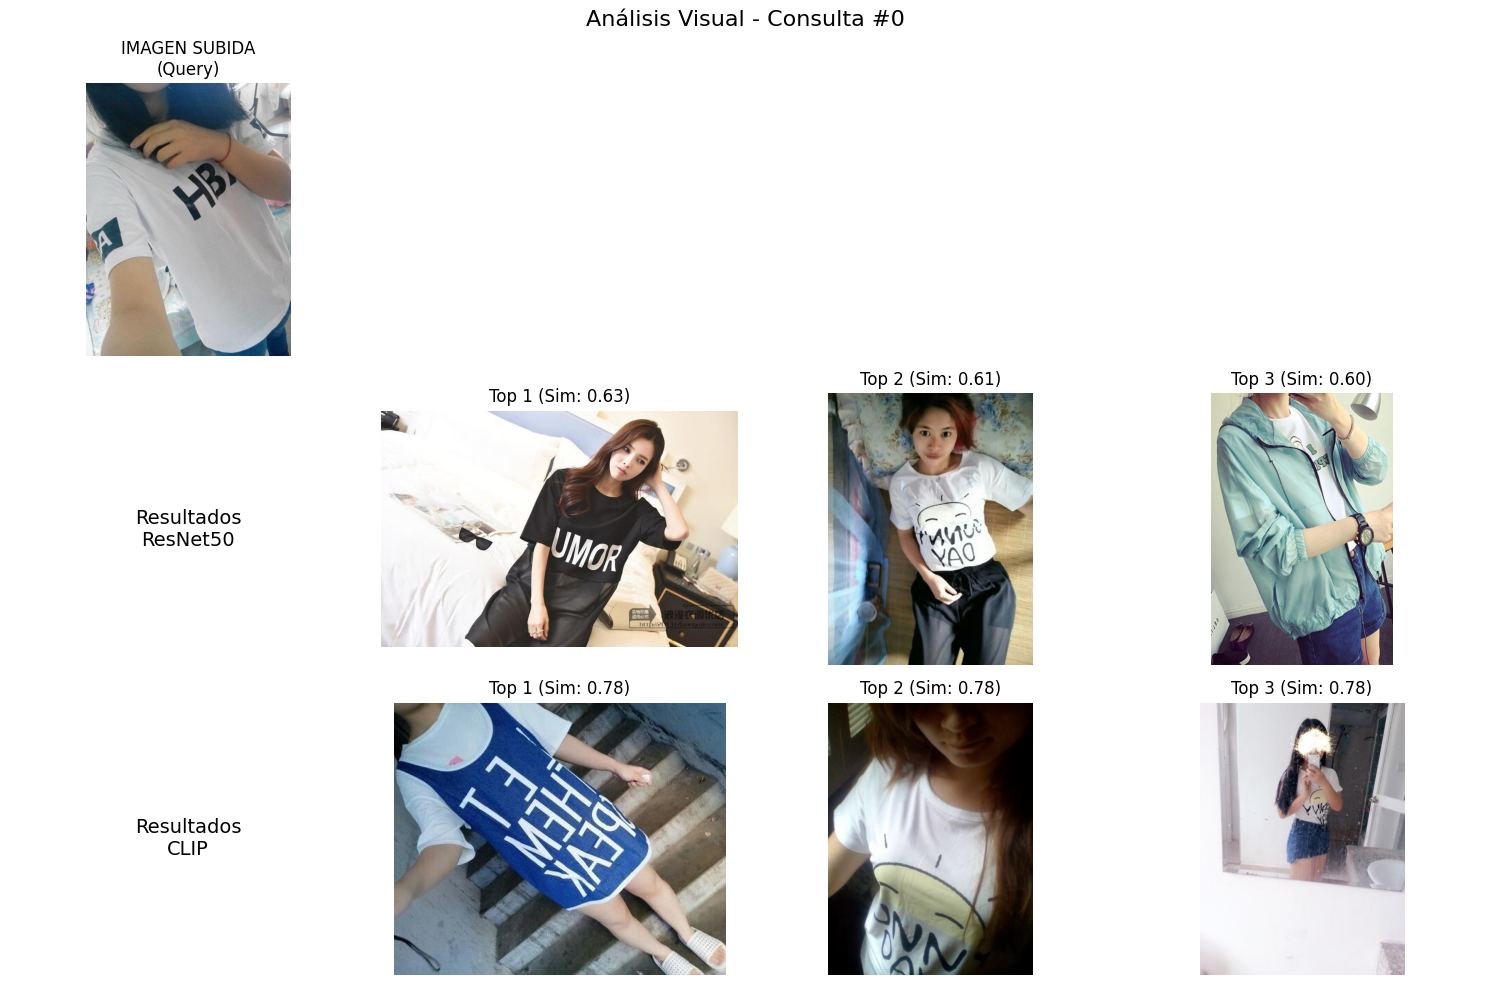

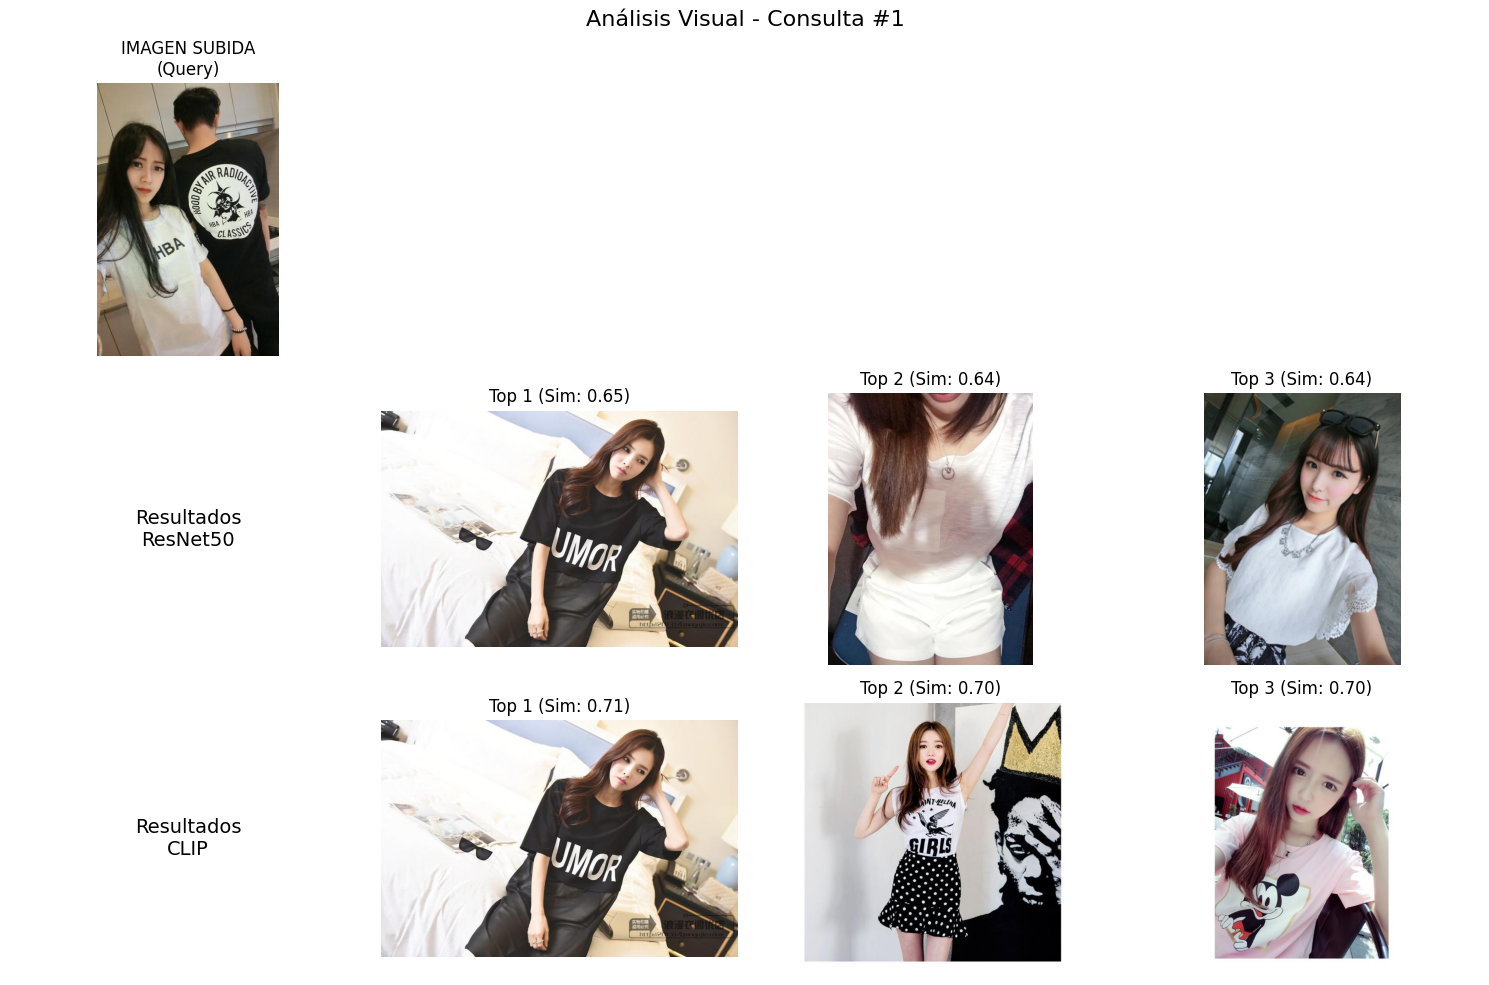

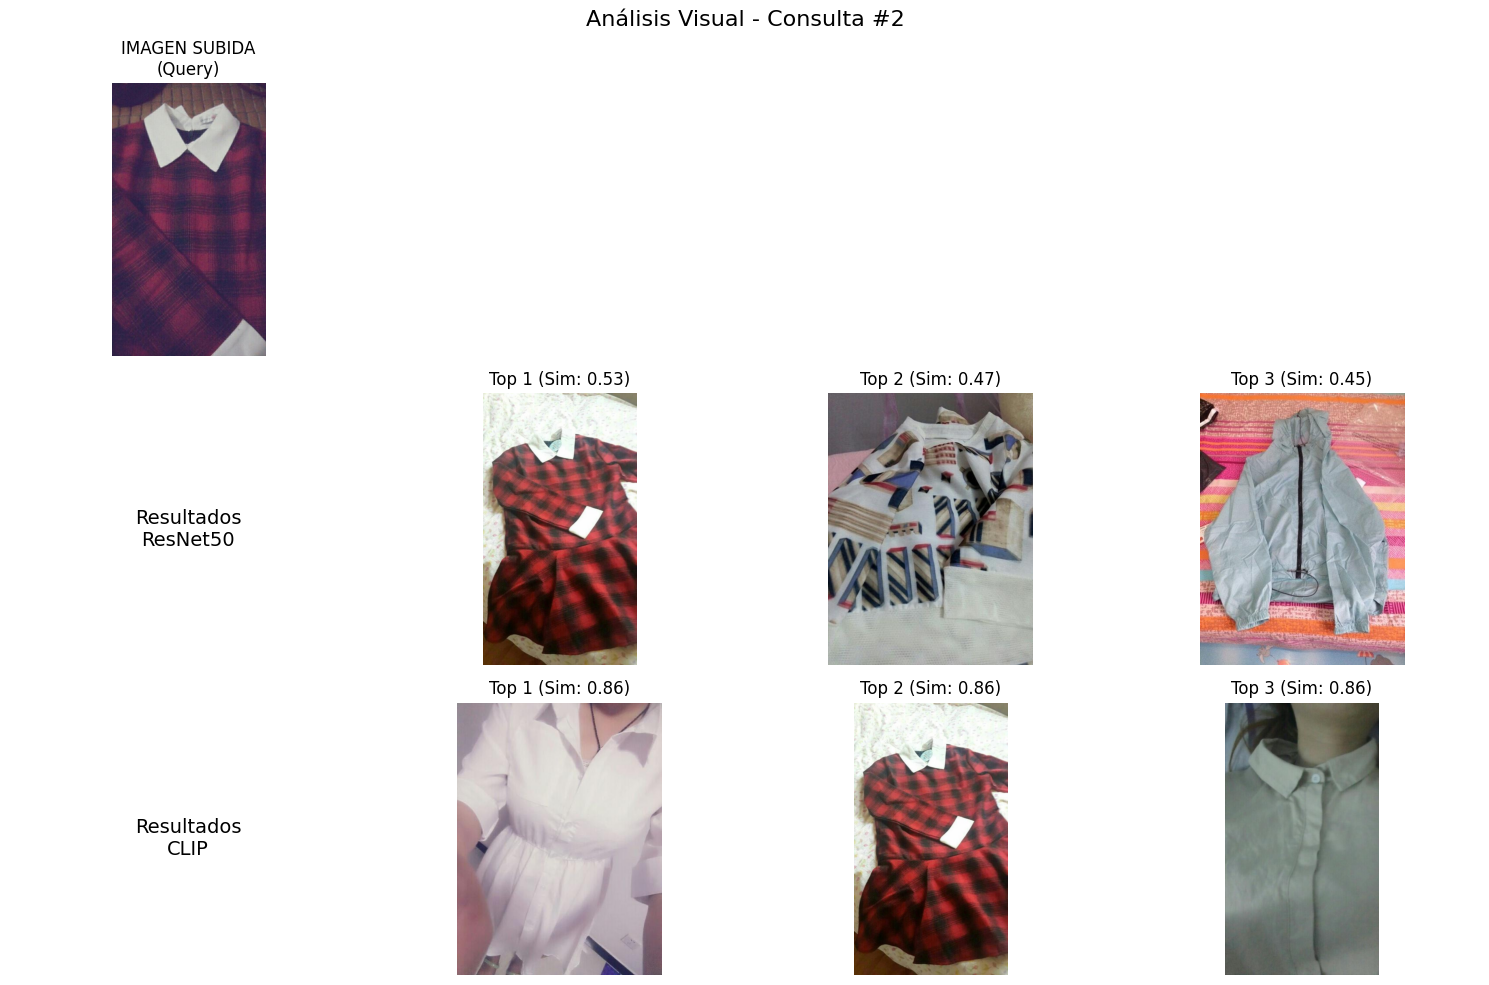

In [37]:
import matplotlib.pyplot as plt

def show_results_visually(query_index, embeddings_modelA, embeddings_modelB, image_paths, top_k=3):
    """Muestra la imagen de consulta y los resultados de ambos modelos."""
    
    # Calculamos similitudes para esta consulta específica
    query_A = embeddings_modelA[query_index].reshape(1, -1)
    sim_A = cosine_similarity(query_A, embeddings_modelA)[0]
    sim_A[query_index] = -1 # Ignorar la propia imagen
    top_indices_A = np.argsort(sim_A)[-top_k:][::-1]
    
    query_B = embeddings_modelB[query_index].reshape(1, -1)
    sim_B = cosine_similarity(query_B, embeddings_modelB)[0]
    sim_B[query_index] = -1
    top_indices_B = np.argsort(sim_B)[-top_k:][::-1]

    # Configuramos el gráfico (Matplotlib)
    fig, axes = plt.subplots(3, top_k + 1, figsize=(15, 10))
    fig.suptitle(f"Análisis Visual - Consulta #{query_index}", fontsize=16)
    
    # Mostrar Query
    ax_query = axes[0, 0]
    ax_query.imshow(Image.open(image_paths[query_index]))
    ax_query.set_title("IMAGEN SUBIDA\n(Query)")
    ax_query.axis('off')
    
    # Ocultar el resto de la primera fila
    for i in range(1, top_k + 1):
        axes[0, i].axis('off')

    # Fila ResNet
    axes[1, 0].text(0.5, 0.5, 'Resultados\nResNet50', fontsize=14, ha='center', va='center')
    axes[1, 0].axis('off')
    for i, idx in enumerate(top_indices_A):
        axes[1, i+1].imshow(Image.open(image_paths[idx]))
        axes[1, i+1].set_title(f"Top {i+1} (Sim: {sim_A[idx]:.2f})")
        axes[1, i+1].axis('off')

    # Fila CLIP
    axes[2, 0].text(0.5, 0.5, 'Resultados\nCLIP', fontsize=14, ha='center', va='center')
    axes[2, 0].axis('off')
    for i, idx in enumerate(top_indices_B):
        axes[2, i+1].imshow(Image.open(image_paths[idx]))
        axes[2, i+1].set_title(f"Top {i+1} (Sim: {sim_B[idx]:.2f})")
        axes[2, i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Vamos a buscar una imagen donde ResNet y CLIP no estén de acuerdo en el Top 1
# o simplemente ver las primeras 3 imágenes de nuestra muestra
print("Generando visualizaciones de comprobación...")
for i in range(3):
    show_results_visually(i, resnet_eval_vecs, clip_eval_vecs, valid_image_paths, top_k=3)